# EQL in SQL Übersetzen — Interaktive Demo

Diese Demo begleitet die Bachelorarbeit *EQL in SQL Übersetzen* und zeigt live, wie EQL-Ausdrücke in SQL übersetzt werden, und wie sich EQL und SQL anhand der in der Arbeit verwendeten Metriken vergleichen.

Diese Umgebung basiert auf `intel4coro/jupyter-ros2:jazzy-py3.12` und bringt ROS2 Jazzy bereits mit, sodass hier auch echte pycram-Klassen (nicht nur die Simulationsklassen) genutzt werden können. Die Beispiele unten nutzen zunächst die Simulationsklassen aus dem Test-Dataset, da sie unabhängig vom konkreten pycram-Setup funktionieren.

## 1. Setup

Wir erstellen eine In-Memory-SQLite-Datenbank und legen Beispielobjekte an.

In [1]:
from sqlalchemy import create_engine, select
from sqlalchemy.orm import sessionmaker, aliased

from krrood.entity_query_language.factories import entity, variable, an, set_of
from krrood.ormatic.eql_interface import eql_to_sql

engine = create_engine("sqlite:///:memory:")
Session = sessionmaker(bind=engine)
session = Session()

import sys
sys.path.insert(0, "/home/jovyan/krrood")

import warnings
from sqlalchemy.exc import SAWarning
warnings.filterwarnings("ignore", category=SAWarning)

import test.krrood_test.conftest

from test.krrood_test.dataset.ormatic_interface import (
    Base,
    SymbolDAO,
    WorldEntityDAO,
    BodyDAO,
    ContainerDAO,
    HandleDAO,
    FixedConnectionDAO,
    MoveActionDAO,
    GraspConfigDAO,
)

Base.metadata.create_all(
    engine,
    tables=[
        SymbolDAO.__table__,
        WorldEntityDAO.__table__,
        BodyDAO.__table__,
        ContainerDAO.__table__,
        HandleDAO.__table__,
        FixedConnectionDAO.__table__,
        MoveActionDAO.__table__,
        GraspConfigDAO.__table__,
    ]
)

print("Setup abgeschlossen.")

INFO:krrood.ormatic.wrapped_table:================================================================================
INFO:krrood.ormatic.wrapped_table:Processing Field FunctionMapping.module_name: str.
INFO:krrood.ormatic.wrapped_table:Parsing as builtin type.
INFO:krrood.ormatic.wrapped_table:================================================================================
INFO:krrood.ormatic.wrapped_table:Processing Field FunctionMapping.function_name: str.
INFO:krrood.ormatic.wrapped_table:Parsing as builtin type.
INFO:krrood.ormatic.wrapped_table:================================================================================
INFO:krrood.ormatic.wrapped_table:Processing Field FunctionMapping.class_name: Optional[str].
INFO:krrood.ormatic.wrapped_table:Parsing as builtin type.
INFO:krrood.ormatic.wrapped_table:================================================================================
INFO:krrood.ormatic.wrapped_table:Processing Field PredicateClassRelation.source: WrappedInstance

Setup abgeschlossen.


## 2. Einfacher Filter

Das einfachste Beispiel: ein WHERE-Filter auf einer einzelnen Tabelle.

In [2]:
from test.krrood_test.dataset.semantic_world_like_classes import Body

b = variable(type_=Body, domain=[])
query = an(entity(b).where(b.size > 5))


translator = eql_to_sql(query, session)

print("EQL:")
print("  an(entity(b).where(b.size > 5))")
print()
print("Generiertes SQL:")
print(" ", str(translator.sql_query).replace("\n", "\n  "))

EQL:
  an(entity(b).where(b.size > 5))

Generiertes SQL:
  SELECT "BodyDAO".database_id, "WorldEntityDAO".database_id AS database_id_1, "SymbolDAO".database_id AS database_id_2, "SymbolDAO".polymorphic_type, "WorldEntityDAO".world_id, "BodyDAO".name, "BodyDAO".size 
  FROM "SymbolDAO" JOIN "WorldEntityDAO" ON "WorldEntityDAO".database_id = "SymbolDAO".database_id JOIN "BodyDAO" ON "BodyDAO".database_id = "WorldEntityDAO".database_id 
  WHERE "BodyDAO".size > :size_1


## 2b. Ergebnis-Verifikation: EQL und SQL liefern dasselbe Ergebnis

Wie in Abschnitt 5.9 der Bachelorarbeit beschrieben, prüft die Testsuite jeden
Übersetzungsvorgang auf zwei Arten: erstens strukturell (stimmt der generierte
SQL-String mit der Erwartung überein), und zweitens semantisch (liefert die
SQL-Ausführung dasselbe Ergebnis wie die lokale EQL-Auswertung). Der zweite
Vergleich ist entscheidend, weil ein strukturell korrekter SQL-String allein
noch nicht garantiert, dass die zurückgegebenen Daten mit der ursprünglichen
EQL-Intention übereinstimmen.

In [3]:
from test.krrood_test.dataset.semantic_world_like_classes import Body

# Echte Python-Objekte für die lokale EQL-Auswertung
grosser_koerper = Body(name="GroßerKörper", size=10)
kleiner_koerper = Body(name="KleinerKörper", size=2)
domain = [grosser_koerper, kleiner_koerper]

b = variable(type_=Body, domain=domain)
query = an(entity(b).where(b.size > 5))

translator = eql_to_sql(query, session)

print("EQL:")
print("  an(entity(b).where(b.size > 5))")
print()
print("Generiertes SQL:")
print(" ", str(translator.sql_query).replace("\n", "\n  "))

from krrood.ormatic.data_access_objects.helper import to_dao  # Name ggf. anpassen, falls anders benannt

# Dieselben Objekte, die auch im domain stehen, in die DB schreiben
session.add(to_dao(grosser_koerper))
session.add(to_dao(kleiner_koerper))
session.commit()

eql_result = list(query.evaluate())
print("EQL-Auswertung (lokal, ohne SQL):")
for r in eql_result:
    print(f"  {r}")

sql_result = translator.evaluate()
print("\nSQL-Auswertung (über den Übersetzer):")
print(f"  {sql_result}")

EQL:
  an(entity(b).where(b.size > 5))

Generiertes SQL:
  SELECT "BodyDAO".database_id, "WorldEntityDAO".database_id AS database_id_1, "SymbolDAO".database_id AS database_id_2, "SymbolDAO".polymorphic_type, "WorldEntityDAO".world_id, "BodyDAO".name, "BodyDAO".size 
  FROM "SymbolDAO" JOIN "WorldEntityDAO" ON "WorldEntityDAO".database_id = "SymbolDAO".database_id JOIN "BodyDAO" ON "BodyDAO".database_id = "WorldEntityDAO".database_id 
  WHERE "BodyDAO".size > :size_1
EQL-Auswertung (lokal, ohne SQL):
  Body(name='GroßerKörper', size=10)

SQL-Auswertung (über den Übersetzer):
  [BodyDAO(name='GroßerKörper', size=10)]


In [4]:
from test.krrood_test.dataset.ormatic_interface import BodyDAO
alle = session.query(BodyDAO).all()
print(f"Anzahl BodyDAO-Zeilen in der DB: {len(alle)}")
for b in alle:
    print(f"  {b}")

Anzahl BodyDAO-Zeilen in der DB: 2
  BodyDAO(name='GroßerKörper', size=10)
  BodyDAO(name='KleinerKörper', size=2)


## 3. Transitiver Attributzugriff

Hier zeigt sich der zentrale Vorteil von EQL: `move.grasp_config.rotate_gripper` navigiert automatisch über eine Beziehung, ohne dass der Fremdschlüsselname bekannt sein muss.

In [5]:
from test.krrood_test.dataset.semantic_world_like_classes import MoveAction

move = variable(type_=MoveAction, domain=[])
query = an(set_of(
    move.robot_x,
    move.robot_y,
    move.grasp_config.rotate_gripper,
    move.grasp_config.approach_direction,
))

translator = eql_to_sql(query, session)

print("EQL:")
print("  an(set_of(move.robot_x, move.robot_y,")
print("            move.grasp_config.rotate_gripper,")
print("            move.grasp_config.approach_direction))")
print()
print("Generiertes SQL:")
print(" ", str(translator.sql_query).replace("\n", "\n  "))

EQL:
  an(set_of(move.robot_x, move.robot_y,
            move.grasp_config.rotate_gripper,
            move.grasp_config.approach_direction))

Generiertes SQL:
  SELECT "MoveActionDAO".robot_x, "MoveActionDAO".robot_y, "GraspConfigDAO_1".rotate_gripper, "GraspConfigDAO_1".approach_direction 
  FROM "SymbolDAO" JOIN "WorldEntityDAO" ON "WorldEntityDAO".database_id = "SymbolDAO".database_id JOIN "MoveActionDAO" ON "MoveActionDAO".database_id = "WorldEntityDAO".database_id JOIN ("SymbolDAO" AS "SymbolDAO_1" JOIN "WorldEntityDAO" AS "WorldEntityDAO_1" ON "WorldEntityDAO_1".database_id = "SymbolDAO_1".database_id JOIN "GraspConfigDAO" AS "GraspConfigDAO_1" ON "GraspConfigDAO_1".database_id = "WorldEntityDAO_1".database_id) ON "GraspConfigDAO_1".database_id = "MoveActionDAO".grasp_config_id


## 4. Multi-Variable-Join

Das Beispiel aus Kapitel 6 der Bachelorarbeit, das den größten Unterschied zwischen EQL und SQL zeigt.

In [6]:
from test.krrood_test.dataset.semantic_world_like_classes import Container, Handle, FixedConnection, World

world = World(1, [Container('C1'), Handle('H1')])
fc = FixedConnection(world.bodies[0], world.bodies[1])
world.connections = [fc]

C = variable(Container, domain=world.bodies)
H = variable(Handle, domain=world.bodies)
FC = variable(FixedConnection, domain=world.connections)

query = an(set_of(C, H, FC).where(C == FC.parent, H == FC.child))
translator = eql_to_sql(query, session)

print("EQL:")
print("  an(set_of(C, H, FC).where(C == FC.parent, H == FC.child))")
print()
print("Generiertes SQL:")
print(" ", str(translator.sql_query).replace("\n", "\n  "))

EQL:
  an(set_of(C, H, FC).where(C == FC.parent, H == FC.child))

Generiertes SQL:
  SELECT "ContainerDAO".database_id, "BodyDAO".database_id AS database_id_1, "WorldEntityDAO".database_id AS database_id_2, "SymbolDAO".database_id AS database_id_3, "SymbolDAO".polymorphic_type, "WorldEntityDAO".world_id, "BodyDAO".name, "BodyDAO".size, "HandleDAO_1".database_id AS database_id_4, "BodyDAO_1".database_id AS database_id_5, "WorldEntityDAO_1".database_id AS database_id_6, "SymbolDAO_1".database_id AS database_id_7, "SymbolDAO_1".polymorphic_type AS polymorphic_type_1, "WorldEntityDAO_1".world_id AS world_id_1, "BodyDAO_1".name AS name_1, "BodyDAO_1".size AS size_1, "FixedConnectionDAO_1".database_id AS database_id_8, "ConnectionDAO_1".database_id AS database_id_9, "WorldEntityDAO_2".database_id AS database_id_10, "SymbolDAO_2".database_id AS database_id_11, "SymbolDAO_2".polymorphic_type AS polymorphic_type_2, "WorldEntityDAO_2".world_id AS world_id_2, "ConnectionDAO_1".parent_id, "Connect

## 5. Metriken aus der Bachelorarbeit nachvollziehen

Wir importieren die Metrikfunktionen aus `test_eql_readability.py` und wenden sie live auf das gerade generierte SQL und den EQL-Ausdruck an.

**Hinweis:** Der Pfad unten geht davon aus, dass krrood unter `/home/jovyan/krrood` liegt (siehe Dockerfile). Falls der Import fehlschlägt, prüfe mit `!find / -name test_eql_readability.py 2>/dev/null` im Terminal, wo die Datei tatsächlich liegt.

In [7]:
import sys
sys.path.insert(0, "/home/jovyan/work/notebooks")

from eql_metrics import (
    character_length,
    technical_noise,
    domain_transparency,
    nesting_depth,
    halstead_volume,
    extrinsic_cognitive_load,
    cognitive_complexity_eql,
    cognitive_complexity_sql,
    fk_error_opportunities,
)

eql_source = "an(set_of(C, H, FC).where(C == FC.parent, H == FC.child))"
sql_source = str(translator.sql_query)

print(f"{'Metrik':<28} {'EQL':>10} {'SQL':>10}")
print("-" * 50)
print(f"{'Zeichenlänge':<28} {character_length(eql_source):>10} {character_length(sql_source):>10}")
print(f"{'Technischer Lärm':<28} {technical_noise(eql_source, True):>10} {technical_noise(sql_source, False):>10}")
print(f"{'Domänen-Transparenz':<28} {domain_transparency(eql_source):>10} {domain_transparency(sql_source):>10}")
print(f"{'Verschachtelungstiefe':<28} {nesting_depth(eql_source):>10} {nesting_depth(sql_source):>10}")
print(f"{'FK-Fehleranfälligkeit':<28} {fk_error_opportunities(eql_source, True):>10} {fk_error_opportunities(sql_source, False):>10}")
print(f"{'Extrinsische Last':<28} {extrinsic_cognitive_load(eql_source, True):>10} {extrinsic_cognitive_load(sql_source, False):>10}")
print(f"{'Kognitive Komplexität':<28} {cognitive_complexity_eql(eql_source)['total']:>10} {cognitive_complexity_sql(sql_source)['total']:>10}")

Metrik                              EQL        SQL
--------------------------------------------------
Zeichenlänge                         50       1844
Technischer Lärm                      0         86
Domänen-Transparenz                 1.0      0.045
Verschachtelungstiefe                 2          1
FK-Fehleranfälligkeit                 0         11
Extrinsische Last                     0        111
Kognitive Komplexität                 4         18


DEBUG:matplotlib.pyplot:Loaded backend inline version unknown.


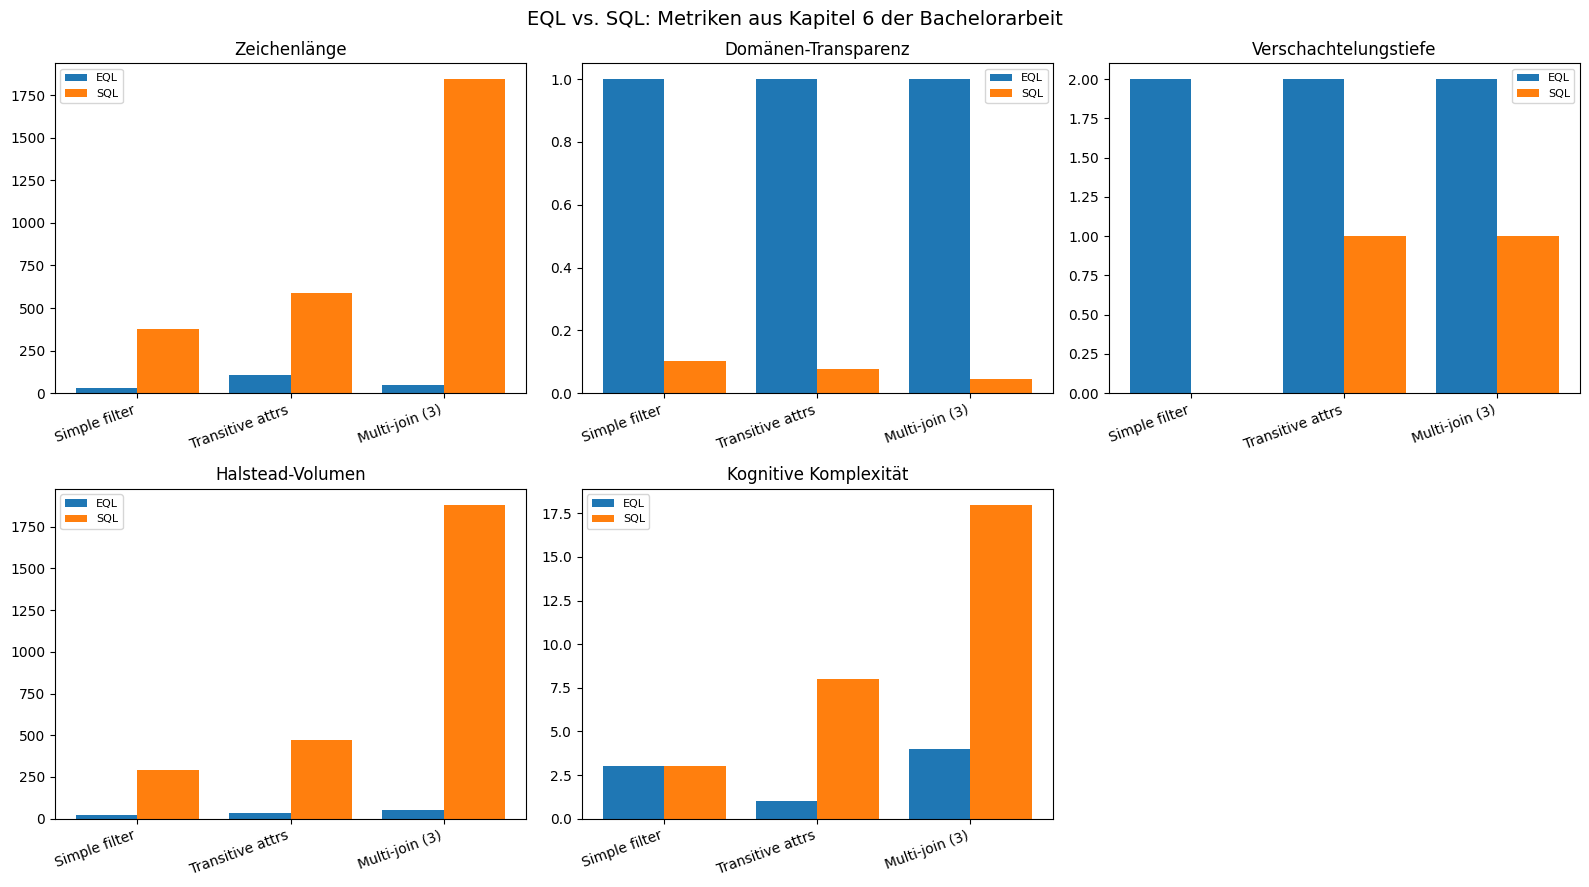

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
import logging
logging.getLogger("matplotlib").setLevel(logging.WARNING)

import sys
sys.path.insert(0, "/home/jovyan/work/notebooks")
from eql_metrics import (
    character_length,
    domain_transparency,
    nesting_depth,
    halstead_volume,
    cognitive_complexity_eql,
    cognitive_complexity_sql,
    EQL_OPERATORS,
    SQL_OPERATORS,
)

from test.krrood_test.dataset.semantic_world_like_classes import (
    Container, Handle, FixedConnection, World, Body, MoveAction
)

def baue_simple_filter():
    b = variable(type_=Body, domain=[])
    query = an(entity(b).where(b.size > 5))
    return eql_to_sql(query, session)

def baue_transitive_attrs():
    move = variable(type_=MoveAction, domain=[])
    query = an(set_of(
        move.robot_x, move.robot_y,
        move.grasp_config.rotate_gripper,
        move.grasp_config.approach_direction,
    ))
    return eql_to_sql(query, session)

def baue_multi_join():
    welt = World(1, [Container("C1"), Handle("H1")])
    fc = FixedConnection(welt.bodies[0], welt.bodies[1])
    welt.connections = [fc]
    C = variable(Container, domain=welt.bodies)
    H = variable(Handle, domain=welt.bodies)
    FC = variable(FixedConnection, domain=welt.connections)
    query = an(set_of(C, H, FC).where(C == FC.parent, H == FC.child))
    return eql_to_sql(query, session)

query_definitionen = [
    ("Simple filter", "an(entity(b).where(b.size > 5))", baue_simple_filter),
    ("Transitive attrs",
     "an(set_of(move.robot_x, move.robot_y, move.grasp_config.rotate_gripper, move.grasp_config.approach_direction))",
     baue_transitive_attrs),
    ("Multi-join (3)",
     "an(set_of(C, H, FC).where(C == FC.parent, H == FC.child))",
     baue_multi_join),
]

namen = []
metriken = {
    "Zeichenlänge": ([], []),
    "Domänen-Transparenz": ([], []),
    "Verschachtelungstiefe": ([], []),
    "Halstead-Volumen": ([], []),
    "Kognitive Komplexität": ([], []),
}

for name, eql_quelltext, baufunktion in query_definitionen:
    trans = baufunktion()
    sql_quelltext = str(trans.sql_query)
    namen.append(name)

    metriken["Zeichenlänge"][0].append(character_length(eql_quelltext))
    metriken["Zeichenlänge"][1].append(character_length(sql_quelltext))

    metriken["Domänen-Transparenz"][0].append(domain_transparency(eql_quelltext))
    metriken["Domänen-Transparenz"][1].append(domain_transparency(sql_quelltext))

    metriken["Verschachtelungstiefe"][0].append(nesting_depth(eql_quelltext))
    metriken["Verschachtelungstiefe"][1].append(nesting_depth(sql_quelltext))

    metriken["Halstead-Volumen"][0].append(halstead_volume(eql_quelltext, EQL_OPERATORS))
    metriken["Halstead-Volumen"][1].append(halstead_volume(sql_quelltext, SQL_OPERATORS))

    metriken["Kognitive Komplexität"][0].append(cognitive_complexity_eql(eql_quelltext)["total"])
    metriken["Kognitive Komplexität"][1].append(cognitive_complexity_sql(sql_quelltext)["total"])

fig, achsen = plt.subplots(2, 3, figsize=(16, 9))
achsen = achsen.flatten()

for idx, (metrik_name, (eql_werte, sql_werte)) in enumerate(metriken.items()):
    ax = achsen[idx]
    x = range(len(namen))
    ax.bar([i - 0.2 for i in x], eql_werte, width=0.4, label="EQL")
    ax.bar([i + 0.2 for i in x], sql_werte, width=0.4, label="SQL")
    ax.set_xticks(list(x))
    ax.set_xticklabels(namen, rotation=20, ha="right")
    ax.set_title(metrik_name)
    ax.legend(fontsize=8)

# Sechstes Subplot leer lassen oder für eine Übersicht nutzen
achsen[5].axis("off")

plt.suptitle("EQL vs. SQL: Metriken aus Kapitel 6 der Bachelorarbeit", fontsize=14)
plt.tight_layout()

## 6. Eigene Query ausprobieren

Passe die Zelle unten an und probiere eigene EQL-Ausdrücke aus.

In [9]:
# Eigene Query hier definieren, z. B.:
action = variable(MoveAction, domain=None)
meine_query = an(entity(action).where(action.robot_x > 0.5))

meine_translator = eql_to_sql(meine_query, session)
print("Generiertes SQL:")
print(str(meine_translator.sql_query))

Generiertes SQL:
SELECT "MoveActionDAO".database_id, "WorldEntityDAO".database_id AS database_id_1, "SymbolDAO".database_id AS database_id_2, "SymbolDAO".polymorphic_type, "WorldEntityDAO".world_id, "MoveActionDAO".robot_x, "MoveActionDAO".robot_y, "MoveActionDAO".hip_rotation, "MoveActionDAO".grasp_config_id 
FROM "SymbolDAO" JOIN "WorldEntityDAO" ON "WorldEntityDAO".database_id = "SymbolDAO".database_id JOIN "MoveActionDAO" ON "MoveActionDAO".database_id = "WorldEntityDAO".database_id 
WHERE "MoveActionDAO".robot_x > :robot_x_1


## 7. Übersetzer


In [12]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from eql_metrics import (
    character_length,
    technical_noise,
    domain_transparency,
    nesting_depth,
    halstead_volume,
    extrinsic_cognitive_load,
    fk_error_opportunities,
    cognitive_complexity_eql,
    cognitive_complexity_sql,
    EQL_OPERATORS,
    SQL_OPERATORS,
)

def beispiel_simple_filter():
    b = variable(type_=Body, domain=[])
    return an(entity(b).where(b.size > 5)), "an(entity(b).where(b.size > 5))"

def beispiel_transitive_attrs():
    move = variable(type_=MoveAction, domain=[])
    query = an(set_of(
        move.robot_x, move.robot_y,
        move.grasp_config.rotate_gripper,
        move.grasp_config.approach_direction,
    ))
    quelltext = ("an(set_of(move.robot_x, move.robot_y, "
                 "move.grasp_config.rotate_gripper, "
                 "move.grasp_config.approach_direction))")
    return query, quelltext

def beispiel_multi_join():
    welt = World(1, [Container("C1"), Handle("H1")])
    fc = FixedConnection(welt.bodies[0], welt.bodies[1])
    welt.connections = [fc]
    C = variable(Container, domain=welt.bodies)
    H = variable(Handle, domain=welt.bodies)
    FC = variable(FixedConnection, domain=welt.connections)
    query = an(set_of(C, H, FC).where(C == FC.parent, H == FC.child))
    quelltext = "an(set_of(C, H, FC).where(C == FC.parent, H == FC.child))"
    return query, quelltext

def beispiel_order_limit():
    b = variable(type_=Body, domain=[])
    query = an(entity(b).where(b.size > 5).ordered_by(b.size).limit(10))
    quelltext = "an(entity(b).where(b.size > 5).ordered_by(b.size).limit(10))"
    return query, quelltext

beispiele = {
    "Einfacher Filter": beispiel_simple_filter,
    "Transitiver Attributzugriff": beispiel_transitive_attrs,
    "Multi-Variable-Join": beispiel_multi_join,
    "Sortierung und Limit": beispiel_order_limit,
}

auswahl = widgets.Dropdown(
    options=list(beispiele.keys()),
    description="EQL-Query:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="400px")
)
ausgabe = widgets.Output()

def zeige_uebersetzung_mit_metriken(change=None):
    with ausgabe:
        clear_output()
        eql_query, eql_quelltext = beispiele[auswahl.value]()
        trans = eql_to_sql(eql_query, session)
        sql_quelltext = str(trans.sql_query)

        print("EQL:")
        print(" ", eql_quelltext)
        print()
        print("Generiertes SQL:")
        print(" ", sql_quelltext.replace("\n", "\n  "))
        print()
        print(f"{'Metrik':<28} {'EQL':>10} {'SQL':>10}")
        print("-" * 50)
        print(f"{'Zeichenlänge':<28} "
              f"{character_length(eql_quelltext):>10} "
              f"{character_length(sql_quelltext):>10}")
        print(f"{'Technischer Lärm':<28} "
              f"{technical_noise(eql_quelltext, True):>10} "
              f"{technical_noise(sql_quelltext, False):>10}")
        print(f"{'Domänen-Transparenz':<28} "
              f"{domain_transparency(eql_quelltext):>10} "
              f"{domain_transparency(sql_quelltext):>10}")
        print(f"{'Verschachtelungstiefe':<28} "
              f"{nesting_depth(eql_quelltext):>10} "
              f"{nesting_depth(sql_quelltext):>10}")
        print(f"{'Halstead-Volumen':<28} "
              f"{halstead_volume(eql_quelltext, EQL_OPERATORS):>10} "
              f"{halstead_volume(sql_quelltext, SQL_OPERATORS):>10}")
        print(f"{'FK-Fehleranfälligkeit':<28} "
              f"{fk_error_opportunities(eql_quelltext, True):>10} "
              f"{fk_error_opportunities(sql_quelltext, False):>10}")
        print(f"{'Extrinsische Last':<28} "
              f"{extrinsic_cognitive_load(eql_quelltext, True):>10} "
              f"{extrinsic_cognitive_load(sql_quelltext, False):>10}")
        print(f"{'Kognitive Komplexität':<28} "
              f"{cognitive_complexity_eql(eql_quelltext)['total']:>10} "
              f"{cognitive_complexity_sql(sql_quelltext)['total']:>10}")

auswahl.observe(zeige_uebersetzung_mit_metriken, names="value")
display(auswahl, ausgabe)
zeige_uebersetzung_mit_metriken()

Dropdown(description='EQL-Query:', layout=Layout(width='400px'), options=('Einfacher Filter', 'Transitiver Att…

Output()

### Was die Metriken aussagen

**Zeichenlänge** — Anzahl der Zeichen ohne Leerzeichen. Kürzere Ausdrücke sind
schneller zu lesen und zu überblicken (Halstead, 1977).

**Technischer Lärm** — Anzahl der Tokens ohne Domänenbedeutung, etwa
Fremdschlüsselsuffixe (`_id`), DAO-Klassennamen oder SQL-Aliase. Je niedriger,
desto direkter spricht der Ausdruck die Sprache der Domäne statt der
Datenbankinfrastruktur (Lawrie et al., 2006).

**Domänen-Transparenz** — Anteil der Wörter im Ausdruck, die aus dem
Domänenmodell stammen, als Wert zwischen 0 und 1. Ein Wert nahe 1 bedeutet,
dass fast der gesamte Ausdruck aus fachlich bedeutsamen Begriffen besteht statt
aus technischen Details (Fowler, 2010).

**Verschachtelungstiefe** — Wie tief Klammern und Unterausdrücke ineinander
verschachtelt sind. Tiefere Verschachtelung erschwert das Nachvollziehen der
Struktur (Campbell, 2018).

**Halstead-Volumen** — Ein Maß für die Informationsmenge eines Ausdrucks,
berechnet aus der Anzahl und Vielfalt der verwendeten Operatoren und Operanden.
Höhere Werte bedeuten, dass mehr unterschiedliche Symbole verarbeitet werden
müssen, um den Ausdruck zu verstehen (Halstead, 1977).

**FK-Fehleranfälligkeit** — Anzahl der Stellen, an denen ein falscher
Fremdschlüssel angegeben werden könnte. Bei EQL ist dieser Wert immer 0, da
der Übersetzer alle Fremdschlüsselbeziehungen automatisch auflöst.

**Extrinsische Last** — Anzahl der Tokens, die ausschließlich wegen der
Datenbankstruktur nötig sind und nichts zur eigentlichen fachlichen Aussage
beitragen, etwa Tabellenaliase oder Zwischenklassen der Vererbungskette.
Niedrigere Werte bedeuten weniger gedankliche Ablenkung durch technische
Details (Sweller, 1988).

**Kognitive Komplexität** — Ein Maß dafür, wie schwer ein Ausdruck gedanklich
nachzuvollziehen ist, basierend auf der Anzahl der Entscheidungspunkte (etwa
Bedingungen und Verknüpfungen) und ihrer Verschachtelung. Niedrigere Werte
bedeuten geringere gedankliche Belastung beim Lesen (Campbell, 2018).

Bei allen Metriken außer der Domänen-Transparenz gilt: niedrigere Werte sind
besser. Eine ausführliche Herleitung und Diskussion der methodischen Grenzen
dieser Metriken findet sich in Abschnitt 5.2 und 6.3.4 der Bachelorarbeit.

## Fazit

Diese Demo hat live gezeigt, was in Kapitel 6 der Bachelorarbeit quantitativ
belegt wird: EQL-Ausdrücke bleiben unabhängig von der Query-Komplexität kurz
und domänennah, während das generierte SQL mit wachsender Anzahl an
Beziehungen und Bedingungen überproportional komplexer wird.

Besonders deutlich wird das am Multi-Variable-Join-Beispiel: Ein EQL-Ausdruck
von unter 60 Zeichen erzeugt SQL mit über 1800 Zeichen und einer
Kognitiven Komplexität, die mehr als viermal so hoch ist wie die des
EQL-Ausdrucks selbst. Gleichzeitig bleibt die Fremdschlüssel-Fehleranfälligkeit
von EQL konstant bei 0, während SQL bei jeder zusätzlichen Verknüpfung neue
potenzielle Fehlerquellen einführt.

Diese Ergebnisse untermauern die zentrale These der Arbeit: EQL macht
Datenbankabfragen für Domänenexpertinnen und Domänenexperten zugänglicher,
ohne Ausdrucksstärke für die in Abschnitt 6.3.4 dokumentierten Grenzfälle
aufzugeben.

Für die vollständige Herleitung der Metriken, die wissenschaftlichen
Grundlagen (Halstead 1977, Campbell 2018, Sweller 1988, Miller 1956) und die
ausführliche Diskussion der Grenzen dieser Evaluation siehe Kapitel 5 und 6
der Bachelorarbeit (`main.pdf` im Repository-Root).

## Weitere Informationen

- Vollständige Bachelorarbeit: siehe `main.pdf` im Repository-Root
- Quellcode des Übersetzers: `krrood/src/krrood/ormatic/eql_interface.py`
- Testsuite (Korrektheit): `test/krrood_test/test_ormatic/test_eql.py`
- Testsuite (Lesbarkeitsmetriken): `test/krrood_test/test_ormatic/test_eql_readability.py`